# Choosing PATH `step_size`

The `step_size` parameter in PATH controls how finely the grid is sampled when calculating the likelihood `p(w|Oi)`. This needs to be small enough to finely sample both the localization size (`a` and `b`) and the galaxy angular size (`ang_size`). In this notebook, I try to figure out some method of choosing `step_size` to properly sample the convolution of the localization and galaxy size.

The relevant code snippets are [here](https://github.com/FRBs/astropath/blob/d73ad5d552fc2694a8333e3b0815c9396ac0d427/astropath/run.py#L179) (setting the `step_size` parameter) and [here](https://github.com/FRBs/astropath/blob/d73ad5d552fc2694a8333e3b0815c9396ac0d427/astropath/bayesian.py#L189) (actually using `step_size` to calculate the likelihood grid). Note that, when calculating the likelihood, the original `step_size` is scaled by each galaxy size. Here's the relevant code snippet:
```
phi_cand = cand_ang_size[icand]   # arcsec
step_size_phi = phi_cand * step_size        # arcsec
box_hwidth = phi_cand * theta_prior['max']  # arcsec

# Grid around the galaxy
ngrid = int(np.round(2 * box_hwidth / step_size_phi))
x = np.linspace(-box_hwidth, box_hwidth, ngrid)
xcoord, ycoord = np.meshgrid(x,x)
theta = np.sqrt(xcoord**2 + ycoord**2)
# p(w|O)
p_wOi = pw_Oi(theta, phi_cand, theta_prior)
```
So, we want `step_size` to be *small*. Currently, it is set as:
```
step_size_max = 2 * 3 * np.nanmin([a, b]) / np.nanmax(cut_catalog['ang_size'])
step_size = np.nanmin([0.1, step_size_max])
```
But that doesn't seem quite right...

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
params = {'axes.labelsize':20,
         'axes.titlesize':20,
         'xtick.labelsize':20,
         'ytick.labelsize':20}
pylab.rcParams.update(params)
import pandas as pd

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from scipy.stats import norm

## Question 1: How many samples do you need to smoothly integrate over a Gaussian distribution?
The convolution of the galaxy and localization will be roughly Gaussian. How fine does the sampling need to be to get a small error on the integral under the curve?

In [3]:
def pw_Oi(theta, phi, theta_prior):
    """
    p(w|O_i) with corrected exp normalisation.
    The fix: norm uses max/scale as the upper limit in units of phi_eff,
    so the truncation (ok_w, in original-phi units) and the norm are consistent.
    """
    p    = np.zeros_like(theta, dtype=float)
    ok_w = theta < theta_prior['max'] * phi          # cutoff at max·phi_orig
 
    if theta_prior['PDF'] == 'core':
        term0    = -phi**2 * np.log(phi)
        term_max = phi * (theta_prior['max']*phi
                         - phi * np.log(phi + theta_prior['max']*phi))
        norm = 2*np.pi*(term_max - term0)
        if np.any(ok_w):
            p[ok_w] = phi / (theta[ok_w] + phi) / norm
 
    elif theta_prior['PDF'] == 'uniform':
        norm = np.pi * (phi * theta_prior['max'])**2
        if np.any(ok_w):
            p[ok_w] = 1.0 / norm
 
    elif theta_prior['PDF'] == 'exp':
        phi_eff     = phi * theta_prior['scale']
        max_in_eff  = theta_prior['max'] / theta_prior['scale']   # ← fix
        norm = 2*np.pi * phi_eff**2 * (
            1 - (1 + max_in_eff) * np.exp(-max_in_eff))
        if np.any(ok_w):
            p[ok_w] = np.exp(-theta[ok_w] / phi_eff) / norm
    else:
        raise IOError("Bad theta PDF")
 
    if norm == 0:
        raise ValueError("Normalisation is zero!")
    return p
 
def gaussian_localiz(xcoord, ycoord, r, a, b, pa_deg=0.):
    """
    2D Gaussian L(x-w) centred at (r, 0) with semi-axes a, b.
 
    pa_deg : position angle of major axis, East-of-North (degrees).
             Here East = +x, North = +y, so PA rotates from y toward x.
    """
    pa  = np.deg2rad(pa_deg)
    dx  = xcoord - r
    dy  = ycoord
 
    # Rotate into ellipse frame
    dx_r =  dx * np.cos(pa) + dy * np.sin(pa)
    dy_r = -dx * np.sin(pa) + dy * np.cos(pa)
 
    return np.exp(-0.5 * (dx_r**2/a**2 + dy_r**2/b**2)) / (2*np.pi*a*b)
 
def build_grids(phi_cand, r, a, b, theta_prior, step_size, pa_deg=0.):
    """
    Two grids:
      integration_grid  — strict PATH convention (box_hwidth = max·phi_cand)
      plot_grid         — extended to show the full Gaussian even when r is large
    """
    step_size_phi = phi_cand * step_size
    box_hwidth    = phi_cand * theta_prior['max']            # PATH integration box
 
    # --- integration grid (matches px_Oi_local exactly) ---
    ngrid_int = int(np.round(2 * box_hwidth / step_size_phi))
    x_int     = np.linspace(-box_hwidth, box_hwidth, ngrid_int)
    xc_int, yc_int = np.meshgrid(x_int, x_int)
    theta_int = np.sqrt(xc_int**2 + yc_int**2)
 
    p_wOi_int = pw_Oi(theta_int.ravel(), phi_cand, theta_prior
                      ).reshape(ngrid_int, ngrid_int)
    L_int     = gaussian_localiz(xc_int, yc_int, r, a, b, pa_deg)
    integ_int = p_wOi_int * L_int
 
    p_xOi = np.nansum(integ_int) * step_size_phi**2          # ← the integral
 
    # sanity checks
    check_pw  = np.nansum(p_wOi_int) * step_size_phi**2
    check_L   = np.nansum(L_int)     * step_size_phi**2
 
    # --- plot grid (extended) ---
    box_plot  = max(box_hwidth, r + 4*max(a, b))
    ngrid_plt = int(np.round(2 * box_plot / step_size_phi))
    x_plt     = np.linspace(-box_plot, box_plot, ngrid_plt)
    xc_plt, yc_plt = np.meshgrid(x_plt, x_plt)
    theta_plt = np.sqrt(xc_plt**2 + yc_plt**2)
 
    p_wOi_plt = pw_Oi(theta_plt.ravel(), phi_cand, theta_prior
                      ).reshape(ngrid_plt, ngrid_plt)
    L_plt     = gaussian_localiz(xc_plt, yc_plt, r, a, b, pa_deg)
    integ_plt = p_wOi_plt * L_plt
 
    return dict(
        # integration result
        p_xOi     = p_xOi,
        check_pw  = check_pw,
        check_L   = check_L,
        # integration grid
        x_int=x_int, p_wOi_int=p_wOi_int, L_int=L_int, integ_int=integ_int,
        step_size_phi=step_size_phi, box_hwidth=box_hwidth,
        # plot grid
        x_plt=x_plt, p_wOi_plt=p_wOi_plt, L_plt=L_plt, integ_plt=integ_plt,
        box_plot=box_plot,
    )
 
def plot_convolution(phi_cand, r, a, b, theta_prior,
                     step_size=0.05, pa_deg=0., outfile=None):
 
    g = build_grids(phi_cand, r, a, b, theta_prior, step_size, pa_deg)
 
    print(f"\n{'='*55}")
    print(f"  phi_cand = {phi_cand}\"   r = {r}\"   a = {a}\"  b = {b}\"")
    print(f"  step_size = {step_size}  (step_size_phi = {g['step_size_phi']:.3f}\")")
    print(f"  Integration box half-width: {g['box_hwidth']:.1f}\"")
    print(f"  ∫ p(w|O_i) dA  = {g['check_pw']:.6f}  (should = 1)")
    print(f"  ∫ L(x-w)   dA  = {g['check_L']:.6f}  (should ≈ 1)")
    print(f"  p(x|O_i)       = {g['p_xOi']:.6f}")
    print(f"{'='*55}\n")
 
    BG = '#0d0d0d'
    fig = plt.figure(figsize=(15, 10), facecolor=BG)
    gs  = GridSpec(2, 3, figure=fig, wspace=0.38, hspace=0.45,
                   left=0.07, right=0.97, top=0.91, bottom=0.08)
 
    xp  = g['x_plt']
    ext = [-g['box_plot'], g['box_plot'], -g['box_plot'], g['box_plot']]
 
    panels = [
        (g['p_wOi_plt'], r'$p(w\,|\,O_i)$',
         'magma',   r'arcsec$^{-2}$'),
        (g['L_plt'],     r'$\mathcal{L}(x{-}w)$',
         'viridis',  r'arcsec$^{-2}$'),
        (g['integ_plt'], r'$\mathcal{L}(x{-}w)\cdot p(w\,|\,O_i)$',
         'plasma',   r'arcsec$^{-4}$'),
    ]
 
    for col, (data, title, cmap, clabel) in enumerate(panels):
        ax = fig.add_subplot(gs[0, col])
        ax.set_facecolor(BG)
 
        vmax = np.nanpercentile(data[data > 0], 99.5) if np.any(data > 0) else 1
        im   = ax.imshow(data, origin='lower', extent=ext,
                         cmap=cmap, vmin=0, vmax=vmax,
                         aspect='equal', interpolation='bilinear')
 
        # Galaxy angular-size circle
        ax.add_patch(plt.Circle((0, 0), phi_cand,
                                color='white', fill=False, lw=0.9, ls=':', alpha=0.6))
        # Galaxy prior boundary
        ax.add_patch(plt.Circle((0, 0), phi_cand * theta_prior['max'],
                                color='white', fill=False, lw=0.6, ls='--', alpha=0.35))
        # Localization ellipse (1σ)
        ax.add_patch(mpatches.Ellipse(
            (r, 0), 2*a, 2*b, angle=pa_deg,
            color='cyan', fill=False, lw=0.9, ls='--', alpha=0.7))
        # Centres
        ax.plot(0,  0, '+', color='white', ms=9, mew=1.4, alpha=0.9, zorder=5)
        ax.plot(r,  0, 'x', color='cyan',  ms=9, mew=1.4, alpha=0.9, zorder=5)
 
        ax.set_title(title, color='white', fontsize=10, pad=5)
        ax.set_xlabel('ΔRA (arcsec)',  color='#cccccc', fontsize=8)
        if col == 0:
            ax.set_ylabel('ΔDec (arcsec)', color='#cccccc', fontsize=8)
        ax.tick_params(colors='#666666', labelsize=7)
        for sp in ax.spines.values():
            sp.set_edgecolor('#444444')
 
        cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
        cb.set_label(clabel, color='#aaaaaa', fontsize=6)
        cb.ax.tick_params(labelsize=6, colors='#aaaaaa')
        cb.outline.set_edgecolor('#444444')
 
    # ── 1D cuts ───────────────────────────────────────────────────────────────
 
    mid   = len(xp) // 2                       # row/col index for y=0 / x=0
    r_idx = int(np.argmin(np.abs(xp - r)))     # column index closest to x=r
 
    c_pw    = '#ff7f50'   # coral
    c_L     = '#90ee90'   # light green
    c_prod  = '#87ceeb'   # sky blue
 
    def _style_ax(ax, xlabel):
        ax.set_facecolor(BG)
        ax.set_xlabel(xlabel, color='#cccccc', fontsize=9)
        ax.set_ylabel('Probability density', color='#cccccc', fontsize=9)
        ax.tick_params(colors='#888888', labelsize=8)
        for sp in ax.spines.values():
            sp.set_edgecolor('#444444')
        ax.legend(fontsize=8, facecolor='#1a1a1a',
                  labelcolor='white', edgecolor='#444444')
        ax.axhline(0, color='#444444', lw=0.5)
 
    # Cut along ΔRA at Dec = 0
    ax1 = fig.add_subplot(gs[1, :2])
    ax1.plot(xp, g['p_wOi_plt'][mid, :], color=c_pw,   lw=1.5,
             label=r'$p(w|O_i)$')
    ax1.plot(xp, g['L_plt'][mid, :],     color=c_L,    lw=1.5,
             label=r'$\mathcal{L}(x{-}w)$')
    ax1.plot(xp, g['integ_plt'][mid, :], color=c_prod, lw=2.0,
             label=r'$\mathcal{L}\cdot p(w|O_i)$')
    ax1.axvline(0, color='white', lw=0.6, ls=':', alpha=0.5)
    ax1.axvline(r, color='cyan',  lw=0.6, ls='--', alpha=0.6)
 
    # shade the prior support
    ax1.axvspan(-phi_cand*theta_prior['max'], phi_cand*theta_prior['max'],
                alpha=0.05, color='white')
    ax1.set_title('1D cut: ΔRA axis  (ΔDec = 0)',
                  color='white', fontsize=10)
    _style_ax(ax1, 'ΔRA  (arcsec)')
 
    # Cut along ΔDec at RA = r
    ax2 = fig.add_subplot(gs[1, 2])
    ax2.plot(xp, g['p_wOi_plt'][:, r_idx], color=c_pw,   lw=1.5,
             label=r'$p(w|O_i)$')
    ax2.plot(xp, g['L_plt'][:, r_idx],     color=c_L,    lw=1.5,
             label=r'$\mathcal{L}$')
    ax2.plot(xp, g['integ_plt'][:, r_idx], color=c_prod, lw=2.0,
             label=r'Product')
    ax2.axvline(0, color='white', lw=0.6, ls=':', alpha=0.5)
    ax2.set_title(f'1D cut: ΔDec axis  (ΔRA = {r:.1f}")',
                  color='white', fontsize=10)
    _style_ax(ax2, 'ΔDec  (arcsec)')
 
    # suptitle
    fig.suptitle(
        rf'$\phi={phi_cand:.1f}$"   $r={r:.1f}$"   '
        rf'$a={a:.1f}$", $b={b:.1f}$"   '
        rf'$\Rightarrow\; p(x|O_i) = {g["p_xOi"]:.5f}$'
        '\n'
        rf'[white $+$ = galaxy centre, cyan $\times$ = localisation centre, '
        rf'dotted circle = $\phi$, dashed circle = max·$\phi$]',
        color='white', fontsize=11, y=0.995
    )

#     fn = outfile or '~/frb_convolution.png'
#     fig.savefig(fn, dpi=150, facecolor=BG)
#     plt.close(fig)
#     print(f"Saved → {fn}")
    return g['p_xOi']

In [49]:
theta_prior = {'PDF': 'exp', 'scale': 0.5, 'max': 6.}

phi_cand = 1. # Size of galaxy, arcsec
r = 0.5 # Galactocentric offset of localization, arcsec
a = 0.1 # Semi-major axis of 1sigma localization, arcsec
b = 0.05 # Semi-minor axis of 1sigma localization, arcsec
pa_deg = 10. # PA of localization
theta_prior = theta_prior
step_size = 0.01 # Step-size, as a fraction of phi_cand

g = build_grids(phi_cand, r, a, b, theta_prior, step_size, pa_deg)

print(f"\n{'='*55}")
print(f"  phi_cand = {phi_cand}\"   r = {r}\"   a = {a}\"  b = {b}\"")
print(f"  step_size = {step_size}  (step_size_phi = {g['step_size_phi']:.3f}\")")
print(f"  Integration box half-width: {g['box_hwidth']:.1f}\"")
print(f"  ∫ p(w|O_i) dA  = {g['check_pw']:.6f}  (should = 1)")
print(f"  ∫ L(x-w)   dA  = {g['check_L']:.6f}  (should ≈ 1)")
print(f"  p(x|O_i)       = {g['p_xOi']:.6f}")
print(f"{'='*55}\n")


  phi_cand = 1.0"   r = 0.5"   a = 0.1"  b = 0.05"
  step_size = 0.01  (step_size_phi = 0.010")
  Integration box half-width: 6.0"
  ∫ p(w|O_i) dA  = 0.998334  (should = 1)
  ∫ L(x-w)   dA  = 0.998334  (should ≈ 1)
  p(x|O_i)       = 0.237034



(-3.0, 3.0)

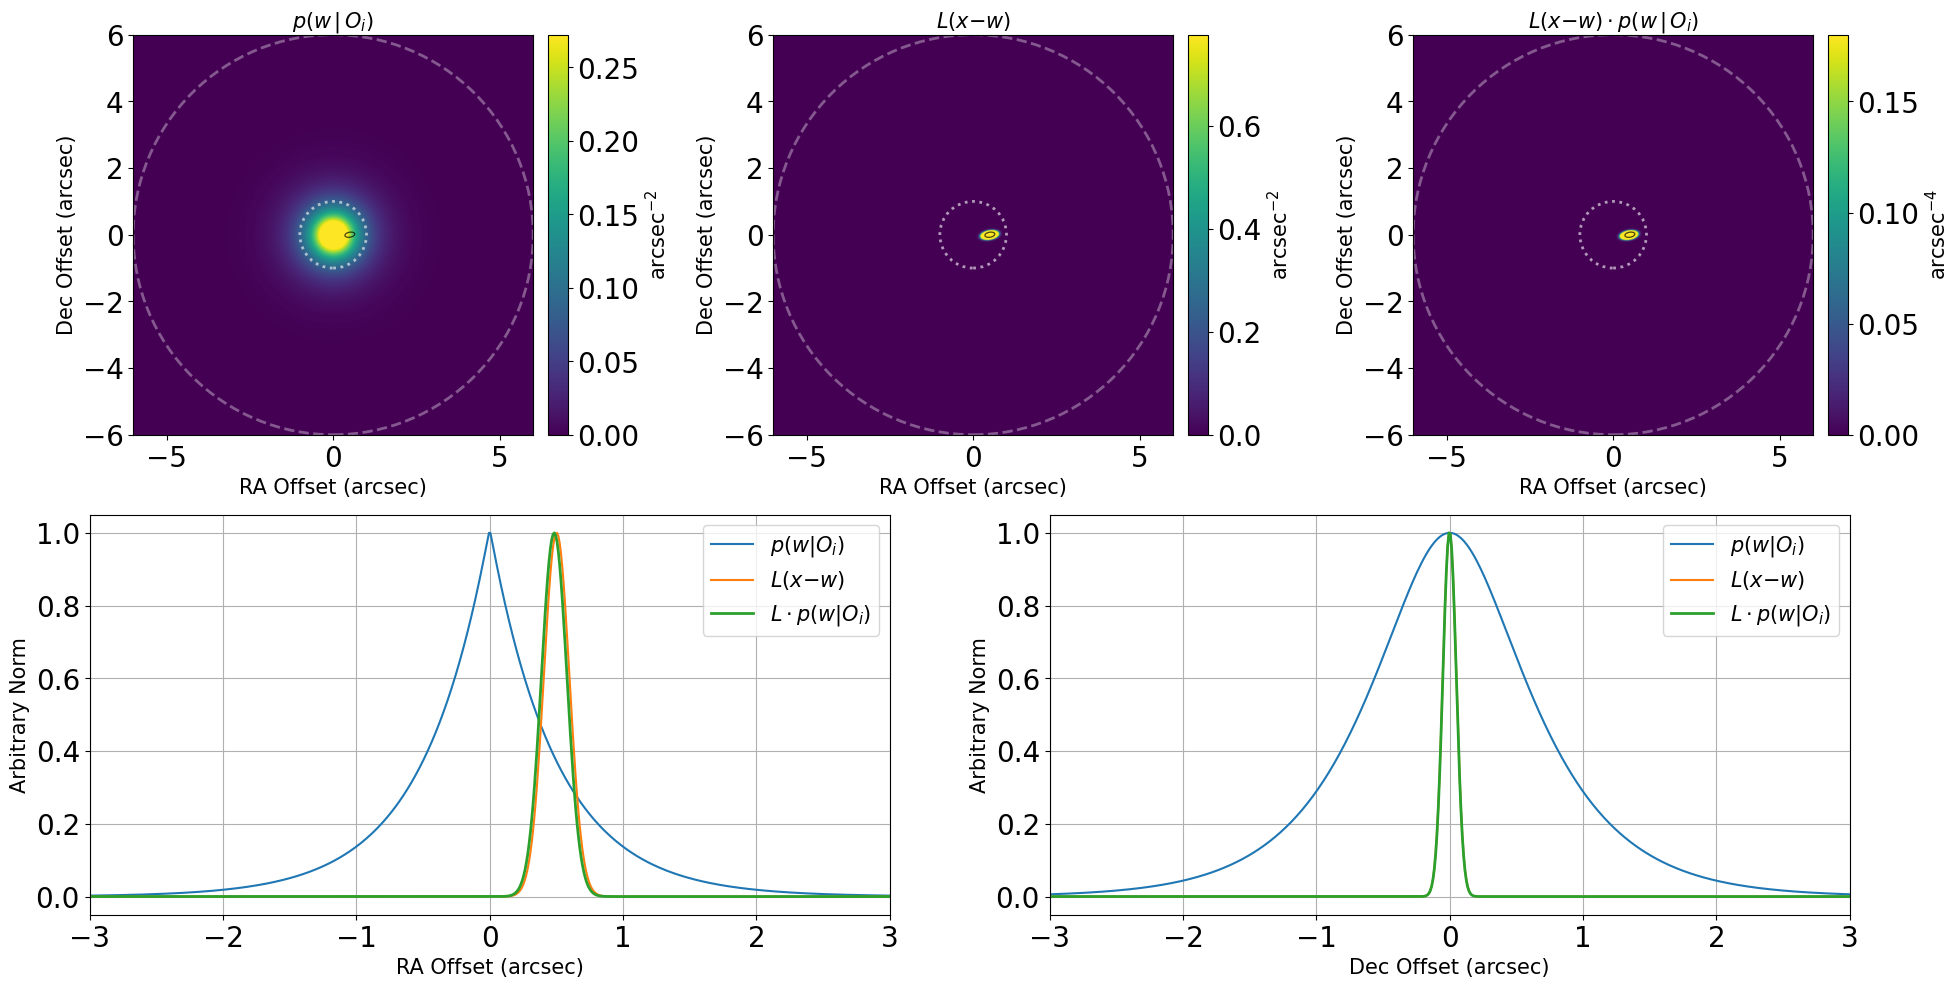

In [50]:
fig = plt.figure(figsize=(16,8))
cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

# (left, bottom, width, height)
sep_w = 0.1
sep_h = 0.1
bottom = 0.5
ax_exp = (0., bottom+sep_h, 0.3, 0.5)
ax_loc = (0.3+sep_w, bottom+sep_h, 0.3, 0.5)
ax_comb = (2*(0.3+sep_w), bottom+sep_h, 0.3, 0.5)
ax_racut = (0., 0., 0.5, 0.5)
ax_deccut = (0.5+sep_w, 0., 0.5, 0.5)

xp  = g['x_plt']
ext = [-g['box_plot'], g['box_plot'], -g['box_plot'], g['box_plot']]

# Plot PDFs

ax = plt.axes(ax_exp)

data = g['p_wOi_plt']
vmax = np.nanpercentile(data[data > 0], 99.5) if np.any(data > 0) else 1
im = ax.imshow(
    data, origin='lower', extent=ext,
    cmap='viridis', vmin=0, vmax=vmax,
    aspect='equal', interpolation='bilinear',
)
# Galaxy angular-size circle
ax.add_patch(plt.Circle((0, 0), phi_cand,
                        color='white', fill=False, lw=2, ls=':', alpha=0.6))
# Galaxy prior boundary
ax.add_patch(plt.Circle((0, 0), phi_cand * theta_prior['max'],
                        color='white', fill=False, lw=2, ls='--', alpha=0.35))
# Localization ellipse (3σ)
ax.add_patch(mpatches.Ellipse(
    (r, 0), 3*a, 3*b, angle=pa_deg,
    color='black', fill=False, lw=0.9, ls='-', alpha=0.7))
cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
cb.set_label(r'arcsec$^{-2}$', color='black', fontsize=15)
ax.set_title(r'$p(w\,|\,O_i)$', color='black', fontsize=15, pad=5)
ax.set_xlabel('RA Offset (arcsec)',  fontsize=15)
ax.set_ylabel('Dec Offset (arcsec)', color='black', fontsize=15)

ax = plt.axes(ax_loc)

data = g['L_plt']
vmax = np.nanpercentile(data[data > 0], 99.5) if np.any(data > 0) else 1
im = ax.imshow(
    data, origin='lower', extent=ext,
    cmap='viridis', vmin=0, vmax=vmax,
    aspect='equal', interpolation='bilinear',
)
# Galaxy angular-size circle
ax.add_patch(plt.Circle((0, 0), phi_cand,
                        color='white', fill=False, lw=2, ls=':', alpha=0.6))
# Galaxy prior boundary
ax.add_patch(plt.Circle((0, 0), phi_cand * theta_prior['max'],
                        color='white', fill=False, lw=2, ls='--', alpha=0.35))
# Localization ellipse (3σ)
ax.add_patch(mpatches.Ellipse(
    (r, 0), 3*a, 3*b, angle=pa_deg,
    color='black', fill=False, lw=0.9, ls='-', alpha=0.7))
cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
cb.set_label(r'arcsec$^{-2}$', color='black', fontsize=15)
ax.set_title(r'$L(x{-}w)$', color='black', fontsize=15, pad=5)
ax.set_xlabel('RA Offset (arcsec)',  fontsize=15)
ax.set_ylabel('Dec Offset (arcsec)', color='black', fontsize=15)

ax = plt.axes(ax_comb)

data = g['integ_plt']
vmax = np.nanpercentile(data[data > 0], 99.5) if np.any(data > 0) else 1
im = ax.imshow(
    data, origin='lower', extent=ext,
    cmap='viridis', vmin=0, vmax=vmax,
    aspect='equal', interpolation='bilinear',
)
# Galaxy angular-size circle
ax.add_patch(plt.Circle((0, 0), phi_cand,
                        color='white', fill=False, lw=2, ls=':', alpha=0.6))
# Galaxy prior boundary
ax.add_patch(plt.Circle((0, 0), phi_cand * theta_prior['max'],
                        color='white', fill=False, lw=2, ls='--', alpha=0.35))
# Localization ellipse (3σ)
ax.add_patch(mpatches.Ellipse(
    (r, 0), 3*a, 3*b, angle=pa_deg,
    color='black', fill=False, lw=0.9, ls='-', alpha=0.7))
cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
cb.set_label(r'arcsec$^{-4}$', color='black', fontsize=15)
ax.set_title(r'$L(x{-}w)\cdot p(w\,|\,O_i)$', color='black', fontsize=15, pad=5)
ax.set_xlabel('RA Offset (arcsec)',  fontsize=15)
ax.set_ylabel('Dec Offset (arcsec)', color='black', fontsize=15)

# Plot cuts
mid = len(xp) // 2                       # row/col index for y=0 / x=0
r_idx = int(np.argmin(np.abs(xp - r)))     # column index closest to x=r

ax = plt.axes(ax_racut)

# Cut along ΔRA at Dec = 0
ax.plot(xp, g['p_wOi_plt'][mid, :] / np.nanmax(g['p_wOi_plt'][mid, :]), color=cycle[0], lw=1.5, label=r'$p(w|O_i)$')
ax.plot(xp, g['L_plt'][mid, :] / np.nanmax(g['L_plt'][mid, :]), color=cycle[1], lw=1.5, label=r'$L(x{-}w)$')
ax.plot(xp, g['integ_plt'][mid, :] / np.nanmax(g['integ_plt'][mid, :]), color=cycle[2], lw=2.0, label=r'$L \cdot p(w|O_i)$')
ax.set_xlabel('RA Offset (arcsec)', color='black', fontsize=15)
ax.set_ylabel('Arbitrary Norm', color='black', fontsize=15)
ax.legend(fontsize=15)
ax.grid()
ax.set_xlim([-3,3])

ax = plt.axes(ax_deccut)

# Cut along ΔRA at Dec = 0
ax.plot(xp, g['p_wOi_plt'][:, r_idx] / np.nanmax(g['p_wOi_plt'][:, r_idx]), color=cycle[0], lw=1.5, label=r'$p(w|O_i)$')
ax.plot(xp, g['L_plt'][:, r_idx] / np.nanmax(g['L_plt'][:, r_idx]), color=cycle[1], lw=1.5, label=r'$L(x{-}w)$')
ax.plot(xp, g['integ_plt'][:, r_idx] / np.nanmax(g['integ_plt'][:, r_idx]), color=cycle[2], lw=2.0, label=r'$L \cdot p(w|O_i)$')
ax.set_xlabel('Dec Offset (arcsec)', color='black', fontsize=15)
ax.set_ylabel('Arbitrary Norm', color='black', fontsize=15)
ax.legend(fontsize=15)
ax.grid()
ax.set_xlim([-3,3])

In [53]:
# Now let's iterate through different step_sizes for this scenario to determine 
# the error for each size
# step_sizes = np.logspace(-3, -1, 100)
step_size_max_old = 2 * 3 * np.nanmin([a, b]) / np.nanmax(phi_cand)
step_size_max_new = np.nanmin([a, b]) / np.nanmax(phi_cand)
mmin = step_size_max_new - 0.01
mmax = step_size_max_old + 0.1
step_sizes = np.linspace(mmin, mmax, 1000)
pws = []
Ls = []
p_xOis = []
for step_size in step_sizes:
    g = build_grids(phi_cand, r, a, b, theta_prior, step_size, pa_deg)
    pws.append(g['check_pw'])
    Ls.append(g['check_L'])
    p_xOis.append(g['p_xOi'])
    
    print(f"\n{'='*55}")
    print(f"  phi_cand = {phi_cand}\"   r = {r}\"   a = {a}\"  b = {b}\"")
    print(f"  step_size = {step_size}  (step_size_phi = {g['step_size_phi']:.3f}\")")
    print(f"  Integration box half-width: {g['box_hwidth']:.1f}\"")
    print(f"  ∫ p(w|O_i) dA  = {g['check_pw']:.6f}  (should = 1)")
    print(f"  ∫ L(x-w)   dA  = {g['check_L']:.6f}  (should ≈ 1)")
    print(f"  p(x|O_i)       = {g['p_xOi']:.6f}")
    print(f"{'='*55}\n")


  phi_cand = 1.0"   r = 0.5"   a = 0.1"  b = 0.05"
  step_size = 0.04  (step_size_phi = 0.040")
  Integration box half-width: 6.0"
  ∫ p(w|O_i) dA  = 0.993339  (should = 1)
  ∫ L(x-w)   dA  = 0.993344  (should ≈ 1)
  p(x|O_i)       = 0.235850


  phi_cand = 1.0"   r = 0.5"   a = 0.1"  b = 0.05"
  step_size = 0.040360360360360364  (step_size_phi = 0.040")
  Integration box half-width: 6.0"
  ∫ p(w|O_i) dA  = 0.991150  (should = 1)
  ∫ L(x-w)   dA  = 0.991131  (should ≈ 1)
  p(x|O_i)       = 0.235324


  phi_cand = 1.0"   r = 0.5"   a = 0.1"  b = 0.05"
  step_size = 0.04072072072072072  (step_size_phi = 0.041")
  Integration box half-width: 6.0"
  ∫ p(w|O_i) dA  = 0.995340  (should = 1)
  ∫ L(x-w)   dA  = 0.995321  (should ≈ 1)
  p(x|O_i)       = 0.236319


  phi_cand = 1.0"   r = 0.5"   a = 0.1"  b = 0.05"
  step_size = 0.041081081081081085  (step_size_phi = 0.041")
  Integration box half-width: 6.0"
  ∫ p(w|O_i) dA  = 0.992440  (should = 1)
  ∫ L(x-w)   dA  = 0.992447  (should ≈ 1)
  


  phi_cand = 1.0"   r = 0.5"   a = 0.1"  b = 0.05"
  step_size = 0.15675675675675677  (step_size_phi = 0.157")
  Integration box half-width: 6.0"
  ∫ p(w|O_i) dA  = 0.986763  (should = 1)
  ∫ L(x-w)   dA  = 1.214494  (should ≈ 1)
  p(x|O_i)       = 0.289646


  phi_cand = 1.0"   r = 0.5"   a = 0.1"  b = 0.05"
  step_size = 0.15711711711711715  (step_size_phi = 0.157")
  Integration box half-width: 6.0"
  ∫ p(w|O_i) dA  = 0.963952  (should = 1)
  ∫ L(x-w)   dA  = 0.728951  (should ≈ 1)
  p(x|O_i)       = 0.171959


  phi_cand = 1.0"   r = 0.5"   a = 0.1"  b = 0.05"
  step_size = 0.1574774774774775  (step_size_phi = 0.157")
  Integration box half-width: 6.0"
  ∫ p(w|O_i) dA  = 0.968379  (should = 1)
  ∫ L(x-w)   dA  = 0.732299  (should ≈ 1)
  p(x|O_i)       = 0.172748


  phi_cand = 1.0"   r = 0.5"   a = 0.1"  b = 0.05"
  step_size = 0.15783783783783786  (step_size_phi = 0.158")
  Integration box half-width: 6.0"
  ∫ p(w|O_i) dA  = 0.972816  (should = 1)
  ∫ L(x-w)   dA  = 0.735654  (sh

Text(0.5, 1.0, '100 by 50 mas, ang_size = 1.0"')

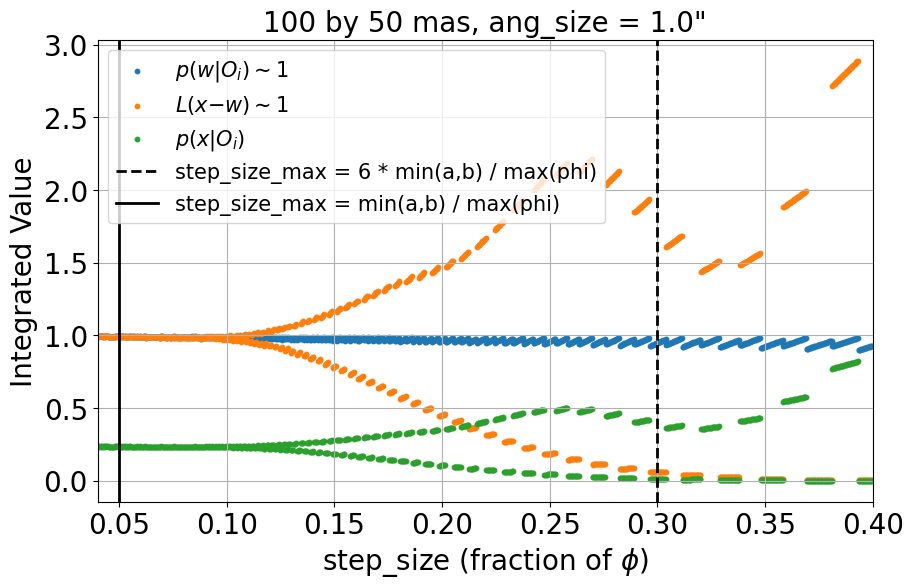

In [54]:
fig = plt.figure(figsize=(10,6))
cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

plt.scatter(step_sizes, pws, s=10, color=cycle[0], label=r'$p(w|O_i) \sim 1$')
plt.scatter(step_sizes, Ls, s=10, color=cycle[1], label=r'$L(x{-}w) \sim 1$')
plt.scatter(step_sizes, p_xOis, s=10, color=cycle[2], label=r'$p(x|O_i)$')
plt.axvline(x=step_size_max_old, color='black', linestyle='dashed', lw=2, label='step_size_max = 6 * min(a,b) / max(phi)')
plt.axvline(x=step_size_max_new, color='black', lw=2, label='step_size_max = min(a,b) / max(phi)')
plt.grid()
plt.xlabel(r'step_size (fraction of $\phi$)')
plt.ylabel('Integrated Value')
plt.legend(fontsize=15)
plt.xlim([mmin, mmax])
plt.title(f'{int(1000*a):d} by {int(1000*b):d} mas, ang_size = {phi_cand:.1f}"')

In [55]:
print(step_size_max_old, step_size_max_new)

0.30000000000000004 0.05


## Question 2: How should we set `step_size` based on `a`, `b`, and `ang_size`?